In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd

In [50]:
# Define categorical data types to reduce memory usage
dtype_dict = {
    "CRIME": "category",
    "VICT SEX": "category",
    "VICT DESCENT": "category",
    "PLACE": "category",
    "WEAPON CATEGORY": "category",
}

# Load merged crime, weather and districts dataset with optimized memory settings
merged_data = pd.read_csv(
    "../processed_data/merged_weather_crime_districts_data.csv",
    dtype=dtype_dict,
    parse_dates=["DATE RPTD", "DATETIME OCC"],
    low_memory=False
)

merged_data.head()

,ID,DATE RPTD,CRIME,VICT AGE,VICT SEX,VICT DESCENT,PLACE,LAT,LON,DATETIME OCC,WEAPON CATEGORY,TEMPERATURE,PERCIPITATION,WIND SPEED,RAIN,SNOWFALL,DISTRICT
0,1307355,2010-02-20,VIOLATION OF COURT ORDER,48,M,H,SINGLE FAMILY DWELLING,33.9825,-118.2695,2010-02-20 13:00:00,No Weapon,14.2,0.0,9.7,0.0,0.0,9
1,11401303,2010-09-13,"VANDALISM - FELONY ($400 & OVER, ALL CHURCH VA...",Unknown,M,W,STREET,33.9599,-118.3962,2010-09-12 00:00:00,No Weapon,16.5,0.0,4.1,0.0,0.0,11
2,70309629,2010-08-09,OTHER MISCELLANEOUS CRIME,Unknown,M,H,ALLEY,34.0224,-118.2524,2010-08-09 15:00:00,No Weapon,25.5,0.0,11.5,0.0,0.0,9
3,90631215,2010-01-05,VIOLATION OF COURT ORDER,47,F,W,STREET,34.1016,-118.3295,2010-01-05 01:00:00,Firearm,8.1,0.0,7.4,0.0,0.0,13
4,100100501,2010-01-03,"RAPE, ATTEMPTED",47,F,H,ALLEY,34.0387,-118.2488,2010-01-02 21:00:00,Strong-Arm,11.6,0.0,8.5,0.0,0.0,14


In [51]:
data = merged_data.copy()
data.head()

,ID,DATE RPTD,CRIME,VICT AGE,VICT SEX,VICT DESCENT,PLACE,LAT,LON,DATETIME OCC,WEAPON CATEGORY,TEMPERATURE,PERCIPITATION,WIND SPEED,RAIN,SNOWFALL,DISTRICT
0,1307355,2010-02-20,VIOLATION OF COURT ORDER,48,M,H,SINGLE FAMILY DWELLING,33.9825,-118.2695,2010-02-20 13:00:00,No Weapon,14.2,0.0,9.7,0.0,0.0,9
1,11401303,2010-09-13,"VANDALISM - FELONY ($400 & OVER, ALL CHURCH VA...",Unknown,M,W,STREET,33.9599,-118.3962,2010-09-12 00:00:00,No Weapon,16.5,0.0,4.1,0.0,0.0,11
2,70309629,2010-08-09,OTHER MISCELLANEOUS CRIME,Unknown,M,H,ALLEY,34.0224,-118.2524,2010-08-09 15:00:00,No Weapon,25.5,0.0,11.5,0.0,0.0,9
3,90631215,2010-01-05,VIOLATION OF COURT ORDER,47,F,W,STREET,34.1016,-118.3295,2010-01-05 01:00:00,Firearm,8.1,0.0,7.4,0.0,0.0,13
4,100100501,2010-01-03,"RAPE, ATTEMPTED",47,F,H,ALLEY,34.0387,-118.2488,2010-01-02 21:00:00,Strong-Arm,11.6,0.0,8.5,0.0,0.0,14


In [52]:
# Drop unnecessary columns for crime prediction
data.drop(columns=["ID", "DATE RPTD", "CRIME", "VICT AGE", "VICT SEX", "VICT DESCENT","PLACE", "WEAPON CATEGORY"], inplace=True)

In [53]:
data = data.rename(columns={"DATETIME OCC": "DATETIME"})

In [54]:
data.head()

,LAT,LON,DATETIME,TEMPERATURE,PERCIPITATION,WIND SPEED,RAIN,SNOWFALL,DISTRICT
0,33.9825,-118.2695,2010-02-20 13:00:00,14.2,0.0,9.7,0.0,0.0,9
1,33.9599,-118.3962,2010-09-12 00:00:00,16.5,0.0,4.1,0.0,0.0,11
2,34.0224,-118.2524,2010-08-09 15:00:00,25.5,0.0,11.5,0.0,0.0,9
3,34.1016,-118.3295,2010-01-05 01:00:00,8.1,0.0,7.4,0.0,0.0,13
4,34.0387,-118.2488,2010-01-02 21:00:00,11.6,0.0,8.5,0.0,0.0,14


In [55]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2119451 entries, 0 to 2119450
Data columns (total 9 columns):
 #   Column         Dtype         
---  ------         -----         
 0   LAT            float64       
 1   LON            float64       
 2   DATETIME       datetime64[ns]
 3   TEMPERATURE    float64       
 4   PERCIPITATION  float64       
 5   WIND SPEED     float64       
 6   RAIN           float64       
 7   SNOWFALL       float64       
 8   DISTRICT       int64         
dtypes: datetime64[ns](1), float64(7), int64(1)
memory usage: 145.5 MB


In [56]:
# Filter rows where year is 2010
data_2010 = data[
    (data['DATETIME'].dt.year == 2010)
]

data_2010.head()

,LAT,LON,DATETIME,TEMPERATURE,PERCIPITATION,WIND SPEED,RAIN,SNOWFALL,DISTRICT
0,33.9825,-118.2695,2010-02-20 13:00:00,14.2,0.0,9.7,0.0,0.0,9
1,33.9599,-118.3962,2010-09-12 00:00:00,16.5,0.0,4.1,0.0,0.0,11
2,34.0224,-118.2524,2010-08-09 15:00:00,25.5,0.0,11.5,0.0,0.0,9
3,34.1016,-118.3295,2010-01-05 01:00:00,8.1,0.0,7.4,0.0,0.0,13
4,34.0387,-118.2488,2010-01-02 21:00:00,11.6,0.0,8.5,0.0,0.0,14


In [57]:
data_2010.shape

(207693, 9)

In [58]:
positives = data_2010.copy()

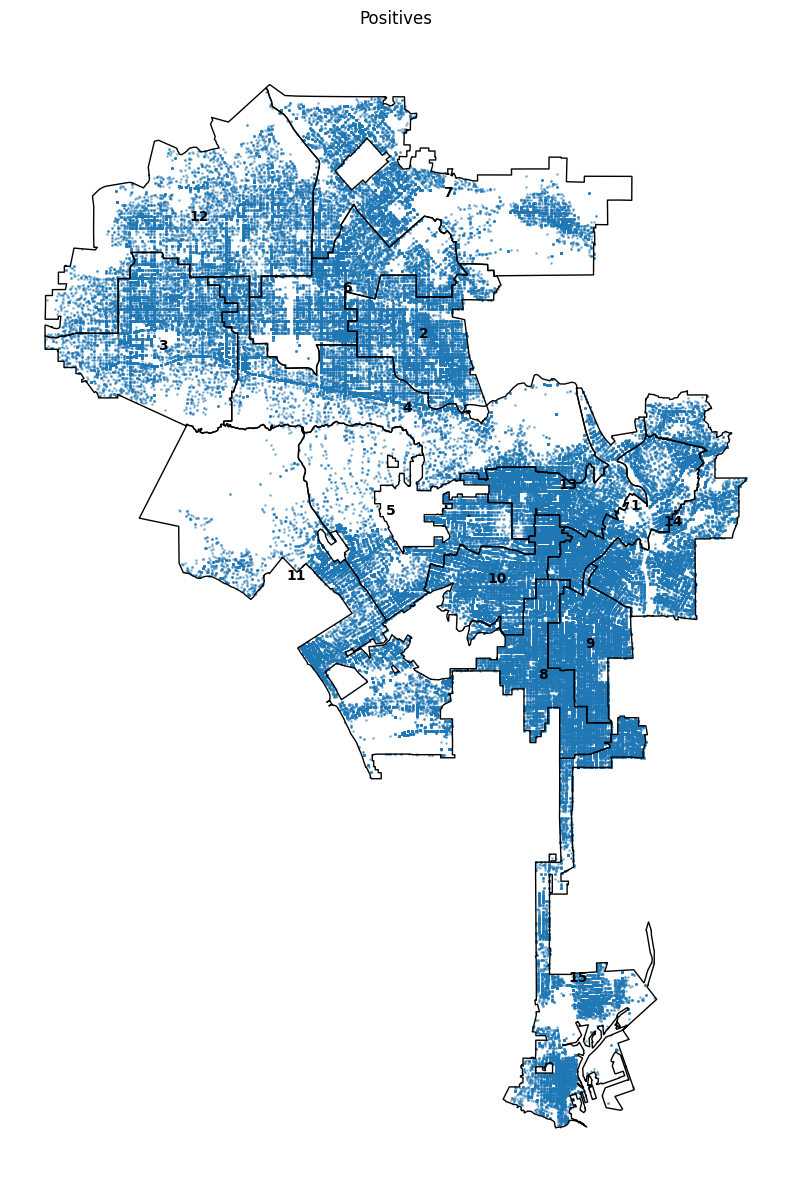

In [59]:
# Convert crime dataframe → GeoDataFrame
positives_gdf = gpd.GeoDataFrame(
    positives,
    geometry=gpd.points_from_xy(positives["LON"], positives["LAT"]),
    crs="EPSG:4326"
)

# Load LA City Council districts shapefile
districts_path = "../raw_data/LA_City_Council_Districts/LA_City_Council_Districts.shp"
districts_gdf = gpd.read_file(districts_path)

# Ensure same CRS
districts_gdf = districts_gdf.to_crs(positives_gdf.crs)

fig, ax = plt.subplots(figsize=(12,12))

# Plot crime points
positives_gdf.plot(
    ax=ax,
    markersize=1,
    alpha=0.4
)

# Plot districts
districts_gdf.plot(
    ax=ax,
    facecolor="none",
    edgecolor="black",
    linewidth=1
)

# Add district labels
for _, row in districts_gdf.iterrows():
    centroid = row.geometry.centroid
    ax.text(
        centroid.x,
        centroid.y,
        str(int(row["DISTRICT"])),
        ha="center",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

plt.title("Positives")
plt.axis("off")
plt.tight_layout()
plt.show()

In [60]:
positives['CRIME HAPPENED'] = 1

In [61]:
positives.head()

,LAT,LON,DATETIME,TEMPERATURE,PERCIPITATION,WIND SPEED,RAIN,SNOWFALL,DISTRICT,CRIME HAPPENED
0,33.9825,-118.2695,2010-02-20 13:00:00,14.2,0.0,9.7,0.0,0.0,9,1
1,33.9599,-118.3962,2010-09-12 00:00:00,16.5,0.0,4.1,0.0,0.0,11,1
2,34.0224,-118.2524,2010-08-09 15:00:00,25.5,0.0,11.5,0.0,0.0,9,1
3,34.1016,-118.3295,2010-01-05 01:00:00,8.1,0.0,7.4,0.0,0.0,13,1
4,34.0387,-118.2488,2010-01-02 21:00:00,11.6,0.0,8.5,0.0,0.0,14,1


In [62]:
# Export the processed DataFrame to CSV
positives.to_csv("../processed_data/positives.csv", index=False)